<a href="https://colab.research.google.com/github/DINESH2841/DINESH2841/blob/main/Oral%20Cancer%20Densenet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print(tf.__version__)
# Clear variables and free memory
%reset -f
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os
from glob import glob
from matplotlib import pyplot
import cv2
import pandas as pd
import numpy as np
import matplotlib.gridspec as gridspec
import seaborn as sns
import itertools
import sklearn
import scipy
import skimage
from skimage.transform import resize
import csv
from tqdm import tqdm
from sklearn import model_selection
from sklearn.model_selection import train_test_split, learning_curve, KFold, cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix
import keras
from tensorflow.keras.utils import to_categorical  # Correct import for to_categorical
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator  # Correct import for ImageDataGenerator
from keras import models, layers, optimizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from keras.layers import Activation, Dense, Dropout, Flatten
from keras.models import Model


2.18.0


In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:

''' Data Path '''
train_path = '/content/drive/MyDrive/Project2025/oralcancer'  # Updated dataset path
File=[]
for f in os.listdir(train_path):
    File += [f]

'''  total number of classes '''
print(File)

''' reading images '''

train_data = []


['cancer-dataset', 'non-cancer-dataset']


In [ ]:

train_data = []

''' label encoding - Assuming two classes based on folder names in new dataset'''
# Adjust mapping based on the folder names in '/content/drive/MyDrive/Project2025/oralcancer 1'
# Let's assume folder names are Class1 and Class2, adjust mapping accordingly after checking.
# For now, let's assume 'Non-Cancer' and 'Cancer' folders are present.
mapping={'Non-Cancer':0, 'Cancer':1} # Adjust this mapping based on actual folder names

count=0

for f in os.listdir(train_path):
    ''' joining path '''
    path = os.path.join(train_path, f)
    for im in os.listdir(path):
        ''' loading an image '''
        img = load_img(os.path.join(path, im), color_mode='rgb', target_size=(128,128))
        ''' converting an image to array '''
        img = img_to_array(img)
        ''' scaling  '''
        img = img / 255.0
        ''' appending image to train_data '''
        train_data.append([img, count])
    count=count+1


In [ ]:
train_images, train_labels = zip(*train_data)

''' converting labels into to_categorical '''
train_labels = to_categorical(train_labels)

''' coverting train_images into numpy array '''
train_images = np.array(train_images)

''' converting train_labesl into numpy array '''
train_labels = np.array(train_labels)

''' shaep of train_images and train_labels '''
print(train_images.shape)
print(train_labels.shape)

(13202, 128, 128, 3)
(13202, 2)


In [ ]:

''' reshaping images '''
train_images = train_images.reshape(-1,128,128,3)


In [ ]:

''' train test split '''
X_train, X_test, y_train, y_test = train_test_split(train_images,train_labels, test_size=0.3,random_state=44)


In [ ]:

''' shape of X_train, X_test, y_train, y_test '''
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(9241, 128, 128, 3)
(3961, 128, 128, 3)
(9241, 2)
(3961, 2)


In [ ]:

''' data Augmentation '''
data_aug = ImageDataGenerator(horizontal_flip=True, vertical_flip=True, rotation_range=20, zoom_range=0.2,
                    width_shift_range=0.2, height_shift_range=0.2, shear_range=0.1, fill_mode="nearest")


In [ ]:

import tensorflow as tf
# Replace MobileNet with DenseNet201
model1 = tf.keras.applications.DenseNet201 (input_shape=(128,128,3),include_top=False,weights='imagenet',pooling='max')
''' freezing layers '''
model1.trainable = False


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:

inp = model1.input
''' Hidden Layer '''
x = tf.keras.layers.Dense(128, activation='relu')(model1.output)
''' Classification Layer '''
out = tf.keras.layers.Dense(2, activation='softmax')(x) # 2 output classes for binary classification

''' Model '''
model = tf.keras.Model(inputs=inp, outputs=out)

''' compile the model '''
model.compile(loss = 'categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:

''' training '''
history=model.fit(data_aug.flow(X_train, y_train, batch_size=32), validation_data=(X_test, y_test), epochs=75)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/75
289/289 ━━━━━━━━━━━━━━━━━━━━ 161s 394ms/step - accuracy: 0.6559 - loss: 0.8540 - val_accuracy: 0.7786 - val_loss: 0.4607
Epoch 2/75
289/289 ━━━━━━━━━━━━━━━━━━━━ 54s 186ms/step - accuracy: 0.7720 - loss: 0.4701 - val_accuracy: 0.7864 - val_loss: 0.4445
Epoch 3/75
289/289 ━━━━━━━━━━━━━━━━━━━━ 48s 167ms/step - accuracy: 0.7854 - loss: 0.4465 - val_accuracy: 0.8162 - val_loss: 0.4039
Epoch 4/75
289/289 ━━━━━━━━━━━━━━━━━━━━ 48s 166ms/step - accuracy: 0.8107 - loss: 0.4126 - val_accuracy: 0.8137 - val_loss: 0.4014
Epoch 5/75
289/289 ━━━━━━━━━━━━━━━━━━━━ 49s 168ms/step - accuracy: 0.8183 - loss: 0.3915 - val_accuracy: 0.8043 - val_loss: 0.4211
Epoch 6/75
289/289 ━━━━━━━━━━━━━━━━━━━━ 48s 167ms/step - accuracy: 0.8174 - loss: 0.3914 - val_accuracy: 0.8124 - val_loss: 0.3995
Epoch 7/75
289/289 ━━━━━━━━━━━━━━━━━━━━ 49s 171ms/step - accuracy: 0.8204 - loss: 0.3796 - val_accuracy: 0.8268 - val_loss: 0.3635
Epoch 8/75
289/289 ━━━━━━━━━━━━━━━━━━━━ 54s 185ms/step - accuracy: 0.8422 - loss: 

In [ ]:

''' prediction '''
y_pred=model.predict(X_test)

''' retreiving max val from predicted values '''
pred = np.argmax(y_pred,axis=1)

''' retreiving max val from actual values '''
ground = np.argmax(y_test,axis=1)

from sklearn.metrics import classification_report

''' classificaion report '''
print(classification_report(ground,pred))


124/124 ━━━━━━━━━━━━━━━━━━━━ 54s 238ms/step
              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1984
           1       0.92      0.91      0.91      1977

    accuracy                           0.91      3961
   macro avg       0.91      0.91      0.91      3961
weighted avg       0.91      0.91      0.91      3961



In [ ]:

# Viewing Model Summary
print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 134, 134, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 64, 64, 64)     │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 64, 64, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 64, 64, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 66, 66, 64)     │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 32, 32, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 32, 32, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 32, 32, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 32, 32, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 32, 32, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 32, 32, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 32, 32, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 32, 32, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 19,060,424 (72.71 MB)

 Trainable params: 246,146 (961.51 KB)

 Non-trainable params: 18,321,984 (69.89 MB)

 Optimizer params: 492,294 (1.88 MB)

None


In [ ]:

##### Checking and extracting the indexes of "Convolutional Layers"
t=list(model.layers)

conv_index=[]
for i in range(len(t)):
  layer=t[i]
  if 'conv' in layer.name:
    conv_index.append(i)

print("Indexes of Convolutional Layers are ",conv_index)


Indexes of Convolutional Layers are  [2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 51, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 139, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 2

In [ ]:

##### Checking layer name and output shapes
for i in conv_index:
  layer=model.layers[i]
  print("layer name is :{}            output Shape is : {}".format(layer.name,layer.output.shape))


layer name is :conv1_conv            output Shape is : (None, 64, 64, 64)
layer name is :conv1_bn            output Shape is : (None, 64, 64, 64)
layer name is :conv1_relu            output Shape is : (None, 64, 64, 64)
layer name is :conv2_block1_0_bn            output Shape is : (None, 32, 32, 64)
layer name is :conv2_block1_0_relu            output Shape is : (None, 32, 32, 64)
layer name is :conv2_block1_1_conv            output Shape is : (None, 32, 32, 128)
layer name is :conv2_block1_1_bn            output Shape is : (None, 32, 32, 128)
layer name is :conv2_block1_1_relu            output Shape is : (None, 32, 32, 128)
layer name is :conv2_block1_2_conv            output Shape is : (None, 32, 32, 32)
layer name is :conv2_block1_concat            output Shape is : (None, 32, 32, 96)
layer name is :conv2_block2_0_bn            output Shape is : (None, 32, 32, 96)
layer name is :conv2_block2_0_relu            output Shape is : (None, 32, 32, 96)
layer name is :conv2_block2_1_conv  

In [ ]:

###### For Demo Visualizing 1st convolutional layer output - Adjust layer index based on DenseNet201 structure
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[2].output) # Check layer index for DenseNet
M_conv_1.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d (ZeroPadding2D)       │ (None, 134, 134, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_conv (Conv2D)                  │ (None, 64, 64, 64)          │           9,408 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,408 (36.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,408 (36.75 KB)

In [ ]:
###### Loading Sample Image for the above layer
''' loading an image '''
# Using an image from the new dataset for visualization
img = load_img("/content/drive/MyDrive/Project2025/oralcancer/cancer-dataset/1.jpg",target_size=(128,128)) # Example image path, adjust as needed

''' converting img to array '''
img = img_to_array(img)

''' scaling '''
img = img / 255.0

''' expanding dimensions '''
img = np.expand_dims(img, axis=0)

feature_maps=M_conv_1.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 128, 128, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step


In [ ]:

###### For Demo Visualizing 1st convolutional layer output - Adjust layer index based on DenseNet201 structure
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[3].output) # Check layer index for DenseNet
M_conv_1.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d (ZeroPadding2D)       │ (None, 134, 134, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_conv (Conv2D)                  │ (None, 64, 64, 64)          │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 64, 64, 64)          │             256 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,664 (37.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,664 (37.75 KB)

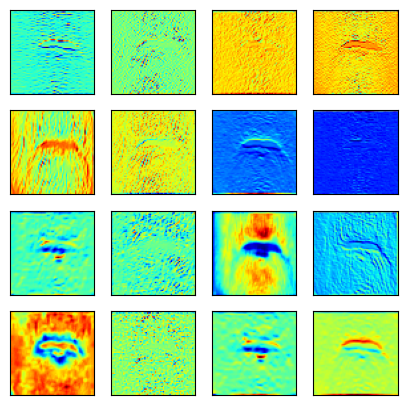

In [ ]:

from matplotlib import pyplot
square=4
ix=1
ax=pyplot.figure(figsize=(5,5))
for i in range(square):
  for j in range(square):
    ax=pyplot.subplot(square,square,ix)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    pyplot.imshow(feature_maps[0,:,:,ix-1],aspect='auto',cmap="jet")
    ix+=1


pyplot.savefig("CO1_DenseNet_Layer2.tiff",format="tiff") # Adjusted filename for clarity
pyplot.show()


In [ ]:

###### For Demo Visualizing 1st convolutional layer output - Adjust layer index based on DenseNet201 structure
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[7].output) # Check layer index for DenseNet
M_conv_1.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d (ZeroPadding2D)       │ (None, 134, 134, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_conv (Conv2D)                  │ (None, 64, 64, 64)          │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 64, 64, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (Activation)              │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_1 (ZeroPadding2D)     │ (None, 66, 66, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_block1_0_bn                    │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,920 (38.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,920 (38.75 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


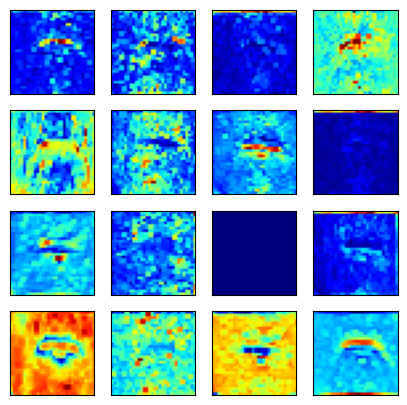

In [ ]:

feature_maps=M_conv_1.predict(img)

from matplotlib import pyplot
square=4
ix=1
ax=pyplot.figure(figsize=(5,5))
for i in range(square):
  for j in range(square):
    ax=pyplot.subplot(square,square,ix)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    pyplot.imshow(feature_maps[0,:,:,ix-1],aspect='auto',cmap="jet")
    ix+=1


pyplot.savefig("CO1_DenseNet_Layer7.tiff",format="tiff") # Adjusted filename for clarity
pyplot.show()


In [ ]:

###### For Demo Visualizing 1st convolutional layer output - Adjust layer index based on DenseNet201 structure
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[9].output) # Check layer index for DenseNet
M_conv_1.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d (ZeroPadding2D)       │ (None, 134, 134, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_conv (Conv2D)                  │ (None, 64, 64, 64)          │           9,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_bn (BatchNormalization)        │ (None, 64, 64, 64)          │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1_relu (Activation)              │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ zero_padding2d_1 (ZeroPadding2D)     │ (None, 66, 66, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling2D)                 │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_block1_0_bn                    │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_block1_0_relu (Activation)     │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2_block1_1_conv (Conv2D)         │ (None, 32, 32, 128)         │           8,192 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,112 (70.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18,112 (70.75 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step


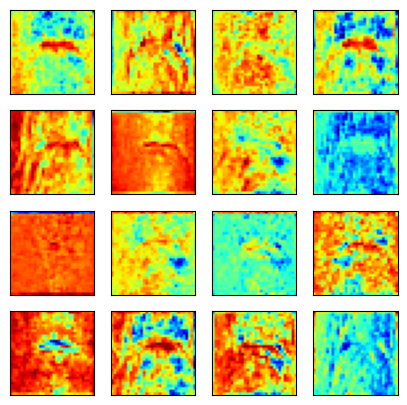

In [ ]:

feature_maps=M_conv_1.predict(img)

from matplotlib import pyplot
square=4
ix=1
ax=pyplot.figure(figsize=(5,5))
for i in range(square):
  for j in range(square):
    ax=pyplot.subplot(square,square,ix)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    pyplot.imshow(feature_maps[0,:,:,ix-1],aspect='auto',cmap="jet")
    ix+=1


pyplot.savefig("CO1_DenseNet_Layer9.tiff",format="tiff") # Adjusted filename for clarity
pyplot.show()

In [ ]:
###### For Demo Visualizing 1st convolutional layer output - Adjust layer index based on DenseNet201 structure
M_conv_1=Model(inputs=model.inputs, outputs=model.layers[14].output) # Check layer index for DenseNet
M_conv_1.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d            │ (None, 134, 134, 3)    │              0 │ input_layer[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 64, 64, 64)     │          9,408 │ zero_padding2d[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 64, 64, 64)     │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 64, 64, 64)     │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ zero_padding2d_1          │ (None, 66, 66, 64)     │              0 │ conv1_relu[0][0]       │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1 (MaxPooling2D)      │ (None, 32, 32, 64)     │              0 │ zero_padding2d_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_bn         │ (None, 32, 32, 64)     │            256 │ pool1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_relu       │ (None, 32, 32, 64)     │              0 │ conv2_block1_0_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 32, 32, 128)    │          8,192 │ conv2_block1_0_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 32, 32, 128)    │            512 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 32, 32, 128)    │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 32, 32, 32)     │         36,864 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_concat       │ (None, 32, 32, 96)     │              0 │ pool1[0][0],           │
│ (Concatenate)             │                        │                │ conv2_block1_2_conv[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block2_0_bn    

 Total params: 55,872 (218.25 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 55,872 (218.25 KB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step


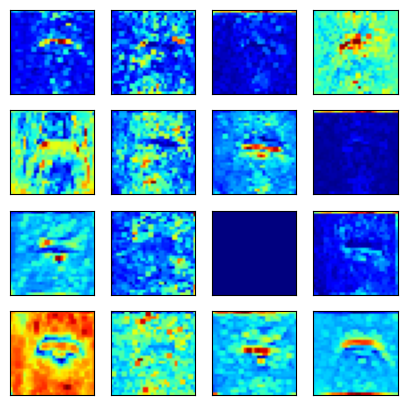

In [ ]:

feature_maps=M_conv_1.predict(img)

from matplotlib import pyplot
square=4
ix=1
ax=pyplot.figure(figsize=(5,5))
for i in range(square):
  for j in range(square):
    ax=pyplot.subplot(square,square,ix)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

    pyplot.imshow(feature_maps[0,:,:,ix-1],aspect='auto',cmap="jet")
    ix+=1


pyplot.savefig("CO1_DenseNet_Layer14.tiff",format="tiff") # Adjusted filename for clarity
pyplot.show()


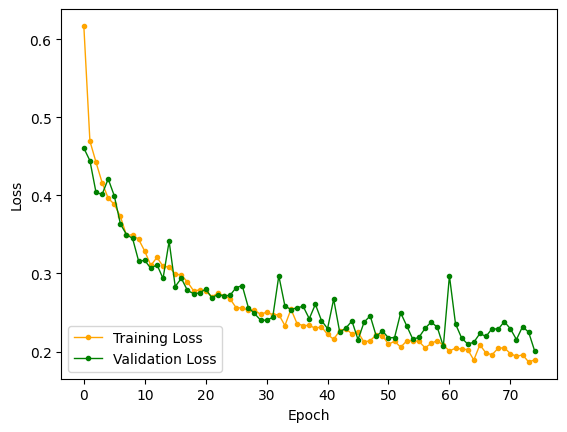

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:

''' training loss and validation loss graph '''
epochs = range(75)
plt.plot(epochs, history.history['loss'], 'orange', marker=".",  label='Training Loss', linewidth=1)
plt.plot(epochs, history.history['val_loss'], 'g', marker=".", label='Validation Loss', linewidth=1)
#plt.title('Training vs validation loss')
plt.xlabel('Epoch'); plt.ylabel('Loss');
plt.legend(loc=3)
plt.figure()
plt.show()
pyplot.savefig("Loss_DenseNet.tiff",format="tiff") # Adjusted filename for clarity


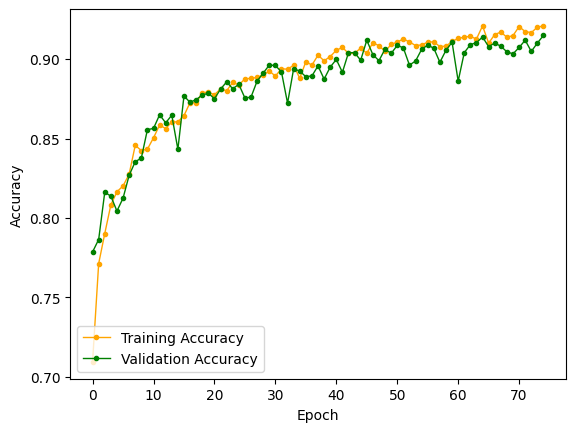

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:

''' training accuracy and validation accuracy graph '''
epochs = range(75)
plt.plot(epochs, history.history['accuracy'], 'orange', marker=".", label='Training Accuracy', linewidth=1)
plt.plot(epochs, history.history['val_accuracy'], 'g', marker=".", label='Validation Accuracy', linewidth=1)
#plt.title('Training vs validation accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy');
plt.legend(loc=3)
plt.figure()
plt.show()
pyplot.savefig("ACC_DenseNet.tiff",format="tiff") # Adjusted filename for clarity


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

data_dir = '/content/drive/MyDrive/Project2025/oralcancer 1'
cancer_dir = os.path.join(data_dir, 'cancer-dataset')
non_cancer_dir = os.path.join(data_dir, 'non-cancer-dataset')

# Create train, val, test directories if they don’t exist
for split in ['train', 'val', 'test']:
    for category in ['cancer', 'non-cancer']:
        os.makedirs(os.path.join(data_dir, split, category), exist_ok=True)

# Get all image paths
cancer_images = [os.path.join(cancer_dir, img) for img in os.listdir(cancer_dir) if img.endswith('.jpg')]
non_cancer_images = [os.path.join(non_cancer_dir, img) for img in os.listdir(non_cancer_dir) if img.endswith('.jpg')]

# Split data (80% train, 10% val, 10% test)
train_cancer, temp_cancer = train_test_split(cancer_images, test_size=0.2, random_state=42)
val_cancer, test_cancer = train_test_split(temp_cancer, test_size=0.5, random_state=42)

train_non_cancer, temp_non_cancer = train_test_split(non_cancer_images, test_size=0.2, random_state=42)
val_non_cancer, test_non_cancer = train_test_split(temp_non_cancer, test_size=0.5, random_state=42)

# Function to copy files
def move_files(file_list, dest_folder):
    for file in file_list:
        shutil.copy(file, dest_folder)

# Move files
move_files(train_cancer, os.path.join(data_dir, 'train', 'cancer'))
move_files(val_cancer, os.path.join(data_dir, 'val', 'cancer'))
move_files(test_cancer, os.path.join(data_dir, 'test', 'cancer'))

move_files(train_non_cancer, os.path.join(data_dir, 'train', 'non-cancer'))
move_files(val_non_cancer, os.path.join(data_dir, 'val', 'non-cancer'))
move_files(test_non_cancer, os.path.join(data_dir, 'test', 'non-cancer'))

print("Sorting complete!")


Dataset sorted and split into train, val, and test sets.


In [ ]:

''' checking accuracy score'''
accuracy = accuracy_score(y_test_arg, Y_pred)
print(accuracy)




NameError: name 'X' is not defined

In [ ]:

import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_arg, Y_pred)
f = sns.heatmap(cm, annot=True, fmt='d', cmap="Reds")
# labels, title and ticks
f.set_xlabel('Predicted label');f.set_ylabel('True label');
#f.set_title('Confusion Matrix');

# Assuming classes are now 'Non-Cancer' and 'Cancer' - adjust labels based on your dataset
f.xaxis.set_ticklabels(['Non-Cancer', 'Cancer']); f.yaxis.set_ticklabels(['Non-Cancer','Cancer']); # Adjusted labels
pyplot.savefig("CM_DenseNet.tiff",format="tiff") # Adjusted filename for clarity


In [ ]:

# Evaluating Metrices

TP = cm[1][1]
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
print('True Positives:', TP)
print('True Negatives:', TN)
print('False Positives:', FP)
print('False Negatives:', FN)


In [ ]:

# calculate accuracy
conf_accuracy = (float (TP+TN) / float(TP + TN + FP + FN))

# calculate mis-classification
conf_misclassification = 1- conf_accuracy

# calculate the sensitivity
conf_sensitivity = (TP / float(TP + FN))
# calculate the specificity
conf_specificity = (TN / float(TN + FP))

# calculate precision
conf_precision = (TN / float(TN + FP)) # Corrected Precision Formula
# calculate NPV
conf_NPV = (TN / float(TN + FN)) # Corrected NPV Formula
# calculate f_1 score
conf_f1 = 2 * ((conf_precision * conf_sensitivity) / (conf_precision + conf_sensitivity))
print('-'*50)
print(f'Accuracy: {round(conf_accuracy,4)}')
print(f'Mis-Classification: {round(conf_misclassification,4)}')
print(f'Sensitivity: {round(conf_sensitivity,4)}')
print(f'Specificity: {round(conf_specificity,4)}')
print(f'Precision: {round(conf_precision,4)}') # Printing corrected precision
print(f'NPV: {round(conf_NPV,4)}') # Printing corrected NPV
print(f'f_1 Score: {round(conf_f1,2)}')


In [ ]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate accuracy
conf_accuracy = (float(TP + TN) / float(TP + TN + FP + FN))

# Calculate mis-classification
conf_misclassification = 1 - conf_accuracy

# Calculate sensitivity
conf_sensitivity = (TP / float(TP + FN))

# Calculate specificity
conf_specificity = (TN / float(TN + FP))

# Calculate precision
conf_precision = (TP / float(TP + FP)) # Corrected Precision Formula

# Calculate NPV
conf_NPV = (TN / float(TN + FN)) # Corrected NPV Formula

# Calculate f_1 score
conf_f1 = 2 * ((conf_precision * conf_sensitivity) / (conf_precision + conf_sensitivity)) # Corrected F1 Score formula - no change needed

# Calculate predicted probabilities
y_scores = model.predict(X_test)[:, 1]  # Assuming you have a model and input data (X) available

# Calculate false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test_arg, y_scores)  # Replace y_true with your true labels

# Calculate AUC score
auc = roc_auc_score(y_test_arg, y_scores)  # Replace y_true with your true labels

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, 'orange',  label='ROC curve (AUC = %0.4f)' % auc, linewidth=2)
plt.plot([0, 1], [0, 1], 'g', linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.02])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

print('-' * 50)
print(f'Accuracy: {round(conf_accuracy, 4)}')
print(f'Mis-Classification: {round(conf_misclassification, 4)}')
print(f'Sensitivity: {round(conf_sensitivity, 4)}')
print(f'Specificity: {round(conf_specificity, 4)}')
print(f'Precision: {round(conf_precision, 4)}') # Printing Corrected Precision
print(f'NPV: {round(conf_NPV, 4)}') # Printing Corrected NPV
print(f'f_1 Score: {round(conf_f1, 2)}') # Printing Corrected F1 Score formula - no change needed